In [ ]:
# Cell 1: Hubungkan Google Colab dengan Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 2: Unzip berkas dataset ke direktori lokal Colab agar pemrosesan gambar lebih cepat
import zipfile
import os

zip_path = '/content/drive/MyDrive/datasets/dataset.zip'
extract_path = '/content/fer2013_extracted/'

# Membuat folder tujuan ekstraksi jika belum ada
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

print("Sedang mengekstrak berkas dataset.zip, mohon tunggu...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Ekstraksi selesai!")
# Menampilkan struktur folder utama hasil unzip
print("Isi direktori hasil ekstraksi:", os.listdir(extract_path))

Sedang mengekstrak berkas dataset.zip, mohon tunggu...
Ekstraksi selesai!
Isi direktori hasil ekstraksi: ['test', 'train']


**Import** **Library**

In [ ]:
# Cell 3: Import seluruh pustaka (library) yang diperlukan untuk manipulasi data, visualisasi, dan modeling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Mengatur tema visualisasi grafik agar terlihat rapi dan profesional
sns.set_theme(style="whitegrid")
print("Semua pustaka berhasil dimuat!")

Semua pustaka berhasil dimuat!


**Load Dataset & Data Preparation**

In [ ]:
# Cell 4: Mengumpulkan jalur file (path) gambar dan memetakan label emosinya berdasarkan nama folder
emotion_label_map = {
    'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'sad': 4, 'surprise': 5, 'neutral': 6,
    'Angry': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Sad': 4, 'Surprise': 5, 'Neutral': 6
}
emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

def load_img_paths(base_path):
    data_list = []
    # Menelusuri seluruh folder secara rekursif
    for root, dirs, files in os.walk(base_path):
        folder_name = os.path.basename(root)
        if folder_name in emotion_label_map:
            label = emotion_label_map[folder_name]
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, file)

                    # Memastikan deteksi split train/test murni dari nama subfolder utama dataset
                    normalized_root = root.replace(base_path, "")
                    split_type = 'train' if 'train' in normalized_root.lower() else 'test'

                    data_list.append({'img_path': img_path, 'emotion': label, 'split': split_type})
    return pd.DataFrame(data_list)

# Eksekusi fungsi load path gambar
df = load_img_paths(extract_path)

print(f"[SUCCESS] Pembuatan peta dataset selesai!")
print(f"Total keseluruhan gambar ditemukan: {df.shape[0]}")
print(f"Jumlah sampel Train: {df[df['split']=='train'].shape[0]}")
print(f"Jumlah sampel Test : {df[df['split']=='test'].shape[0]}")
print("\nMenampilkan 5 baris pertama DataFrame struktur path:")
display(df.head())

[SUCCESS] Pembuatan peta dataset selesai!
Total keseluruhan gambar ditemukan: 35887
Jumlah sampel Train: 28709
Jumlah sampel Test : 7178

Menampilkan 5 baris pertama DataFrame struktur path:


,img_path,emotion,split
0,/content/fer2013_extracted/test/angry/PrivateT...,0,test
1,/content/fer2013_extracted/test/angry/PublicTe...,0,test
2,/content/fer2013_extracted/test/angry/PrivateT...,0,test
3,/content/fer2013_extracted/test/angry/PrivateT...,0,test
4,/content/fer2013_extracted/test/angry/PrivateT...,0,test


**Data Cleansing**

In [ ]:
# Cell 5: Pemeriksaan Missing Values dan Duplikasi Berkas Gambar
print("1. Memeriksa adanya Missing Values pada struktur data:")
print(df.isnull().sum())

print("\n2. Memeriksa adanya duplikasi path gambar:")
duplicate_count = df['img_path'].duplicated().sum()
print(f"Jumlah baris duplikat ditemukan: {duplicate_count}")

# Jika ditemukan data duplikat, lakukan penghapusan baris tersebut
if duplicate_count > 0:
    df.drop_duplicates(subset=['img_path'], inplace=True)
    print("[CLEANSED] Baris data duplikat berhasil dibersihkan.")

print(f"\nTotal data bersih yang siap diproses ke tahap EDA: {len(df)}")

1. Memeriksa adanya Missing Values pada struktur data:
img_path    0
emotion     0
split       0
dtype: int64

2. Memeriksa adanya duplikasi path gambar:
Jumlah baris duplikat ditemukan: 0

Total data bersih yang siap diproses ke tahap EDA: 35887


**EDA (Analisis Sebaran Kelas)**

/tmp/ipykernel_739/1048186423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='emotion', data=df, palette='viridis')


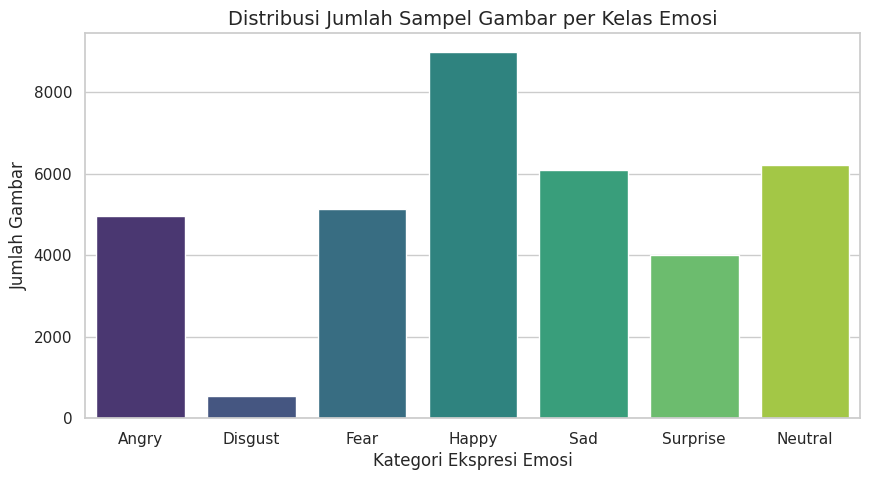

Detail angka distribusi jumlah sampel gambar per kelas:
  - Kelas 0 (Angry): 4953 gambar
  - Kelas 1 (Disgust): 547 gambar
  - Kelas 2 (Fear): 5121 gambar
  - Kelas 3 (Happy): 8989 gambar
  - Kelas 4 (Sad): 6077 gambar
  - Kelas 5 (Surprise): 4002 gambar
  - Kelas 6 (Neutral): 6198 gambar


In [ ]:
# Cell 6: Visualisasi Distribusi Jumlah Gambar Per Kelas Emosi
plt.figure(figsize=(10, 5))
sns.countplot(x='emotion', data=df, palette='viridis')
plt.xticks(ticks=range(7), labels=[emotion_map[i] for i in range(7)])
plt.title("Distribusi Jumlah Sampel Gambar per Kelas Emosi", fontsize=14)
plt.xlabel("Kategori Ekspresi Emosi", fontsize=12)
plt.ylabel("Jumlah Gambar", fontsize=12)
plt.show()

print("Detail angka distribusi jumlah sampel gambar per kelas:")
counts = df['emotion'].value_counts().sort_index()
for i, count in enumerate(counts):
    print(f"  - Kelas {i} ({emotion_map[i]}): {count} gambar")

**EDA - Visualizing Samples**

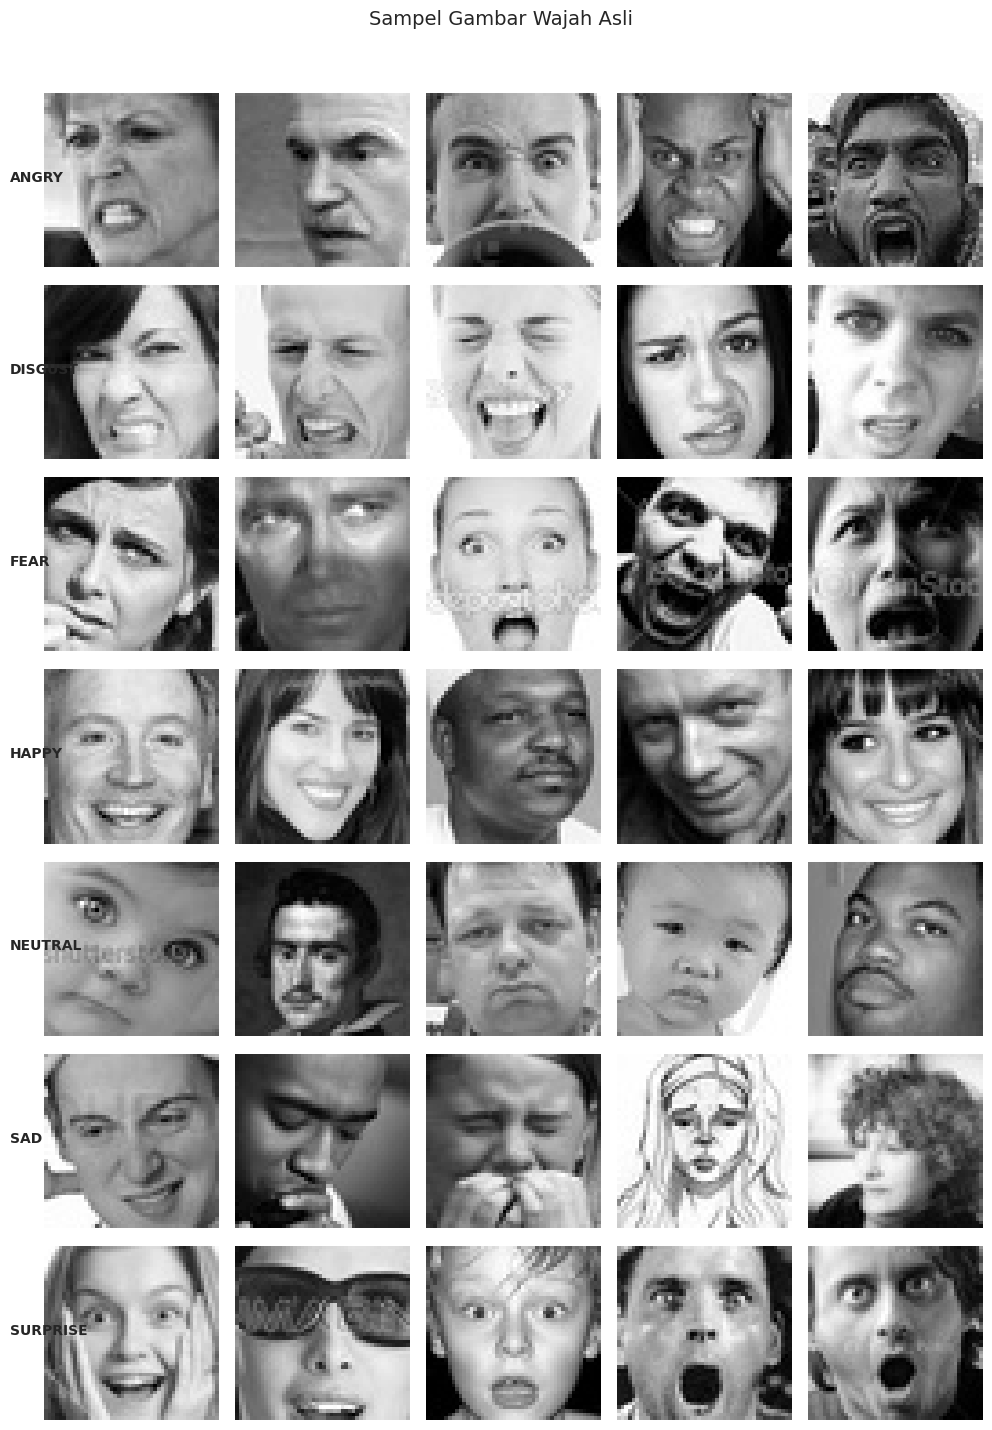

In [ ]:
# Cell 7: Visualisasi Gambar Sampel & Distribusi Kelas

# Definisikan direktori train dan test
train_dir = os.path.join(extract_path, 'train')
test_dir = os.path.join(extract_path, 'test')

emotion_folder_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
display_classes = [emotion_map[emotion_label_map[name]] for name in emotion_folder_names]

# Visualisasi Sampel Gambar
fig, axes = plt.subplots(len(display_classes), 5, figsize=(10, 2 * len(display_classes)))
for r, emotion_folder_name in enumerate(emotion_folder_names):
    emotion_display_name = display_classes[r]
    emotion_folder_path = os.path.join(train_dir, emotion_folder_name)
    image_files = [f for f in os.listdir(emotion_folder_path) if not f.startswith('.')][:5]
    for c, img_name in enumerate(image_files):
        img_path = os.path.join(emotion_folder_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        axes[r, c].imshow(img, cmap='gray')
        axes[r, c].axis('off')
        if c == 0:
            axes[r, c].text(-10, 24, emotion_display_name.upper(), fontsize=10, fontweight='bold')
plt.suptitle('Sampel Gambar Wajah Asli', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Augmentasi Data & Generator Aliran Gambar**

In [ ]:
# Cell 8: Image Data Augmentation dan Persiapan Generator Berbasis Aliran Folder
# Nilai pergeseran diperkecil (0.1) agar fitur wajah esensial resolusi kecil 48x48 tidak terpotong keluar bingkai

train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,             # Normalisasi piksel langsung ke skala [0,1]
    rotation_range=12,          # Rotasi aman maksimal 12 derajat
    width_shift_range=0.1,      # Pergeseran horizontal ketat 10% agar posisi mata/mulut aman
    height_shift_range=0.1,     # Pergeseran vertikal ketat 10%
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,       # Membalik objek wajah (sifat emosi simetris)
    fill_mode='nearest'
)

# Generator validasi/uji murni hanya melakukan normalisasi skala tanpa mengubah bentuk objek wajah asli
test_datagen = ImageDataGenerator(rescale=1./255)

print("Memuat Aliran Data Latih (Train Generator)...")
train_generator = train_datagen_augmented.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode='sparse',        # Menggunakan format 'sparse' (integer label) agar sinkron dengan class weights
    shuffle=True
)

print("\nMemuat Aliran Data Uji (Test Generator)...")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode='sparse',        # SINKRON KE SPARSE
    shuffle=False               # Data uji dikunci agar urutannya konsisten saat dievaluasi report matematika
)

Memuat Aliran Data Latih (Train Generator)...
Found 28709 images belonging to 7 classes.

Memuat Aliran Data Uji (Test Generator)...
Found 7178 images belonging to 7 classes.


**Pengaturan Class Weights & Callbacks**

In [ ]:
# Cell 9: Setup Bobot Penyeimbang Distribusi Kelas & Optimasi Pelatihan Callbacks

# 1. Menghitung Class Weights secara dinamis dari distribusi generator latih
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights_array))
print("⚖️ Proporsi Penyeimbang Kelas (Class Weights):", class_weights_dict)

# 2. Penyetelan Callbacks Pelatihan
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,                 # Hentikan otomatis jika 7 epoch tidak ada perbaikan loss validasi
    restore_best_weights=True,  # Kembalikan bobot terbaik yang sempat dicapai sebelum berhenti
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/content/best_emotion_model.keras', # Ekstensi format .keras disimpan lokal Colab
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
print("✅ Parameter Callbacks berhasil dikonfigurasi.")

⚖️ Proporsi Penyeimbang Kelas (Class Weights): {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}
✅ Parameter Callbacks berhasil dikonfigurasi.


## Pembuatan Arsitektur Model Deep CNN

In [ ]:
# Cell 10: Arsitektur Deep CNN dengan Batch Normalization untuk Stabilitas Gradien dan Akurasi Tinggi

model = Sequential([
    tf.keras.Input(shape=(48, 48, 1)),

    # Blok Konvolusi 1
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Blok Konvolusi 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Blok Konvolusi 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Blok Lapisan Klasifikasi (Fully Connected Layer)
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

# Menggunakan sparse_categorical_crossentropy agar 100% sinkron dengan generator dan class weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,470,951 (5.61 MB)

 Trainable params: 1,469,543 (5.61 MB)

 Non-trainable params: 1,408 (5.50 KB)

**Modeling (Baseline)**

In [ ]:
# Cell 11: Proses Eksekusi Pelatihan / Fitting CNN Model
# Silakan jalankan cell ini dan tunggu hingga pelatihan selesai atau terkena Early Stopping

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    class_weight=class_weights_dict,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1782 - loss: 2.4503
Epoch 1: val_accuracy improved from None to 0.20939, saving model to /content/best_emotion_model.keras

Epoch 1: finished saving model to /content/best_emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 57s 94ms/step - accuracy: 0.1933 - loss: 2.2352 - val_accuracy: 0.2094 - val_loss: 1.9716
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2411 - loss: 1.9106
Epoch 2: val_accuracy improved from 0.20939 to 0.38660, saving model to /content/best_emotion_model.keras

Epoch 2: finished saving model to /content/best_emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.2626 - loss: 1.8484 - val_accuracy: 0.3866 - val_loss: 1.6400
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3366 - loss: 1.6835
Epoch 3: val_accuracy improved from 0.38660 to 0.41098, saving model to /content/best_emotion_model.keras

Epoch 3: finished saving model to /content/best

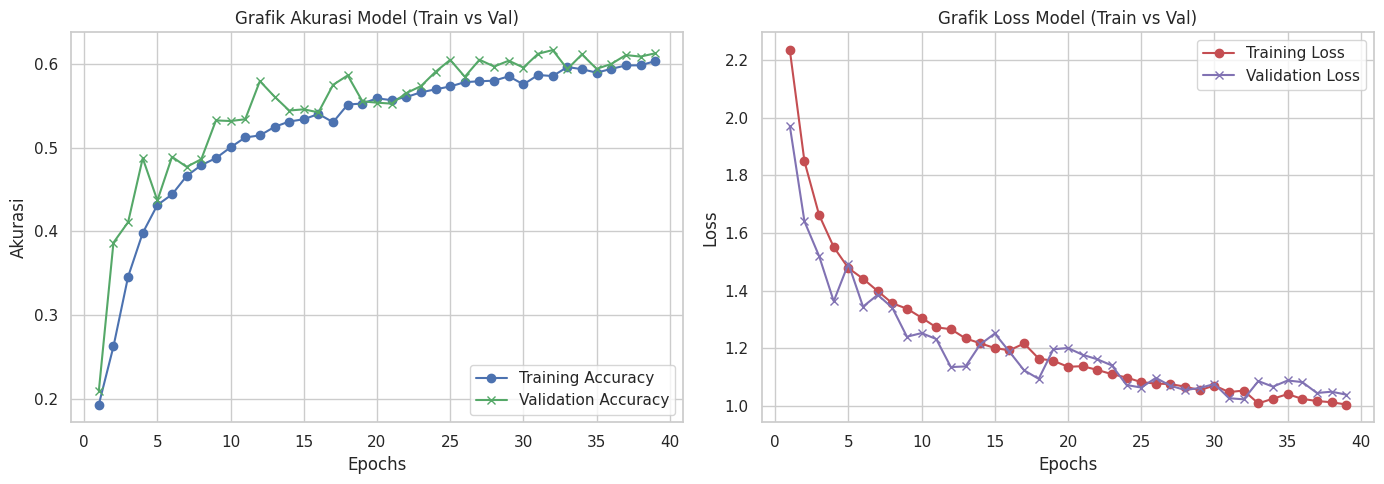

In [ ]:
# Cell 12: Plot Grafik Metrik Evaluasi Proses Pelatihan Model

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='b', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='g', marker='x')
plt.title('Grafik Akurasi Model (Train vs Val)')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='r', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='m', marker='x')
plt.title('Grafik Loss Model (Train vs Val)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Modelling - training**

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step
=================== CLASSIFICATION REPORT ===================
              precision    recall  f1-score   support

       Angry       0.62      0.45      0.52       958
     Disgust       0.38      0.76      0.51       111
        Fear       0.53      0.25      0.34      1024
       Happy       0.81      0.86      0.83      1774
         Sad       0.49      0.72      0.58      1233
    Surprise       0.50      0.50      0.50      1247
     Neutral       0.75      0.75      0.75       831

    accuracy                           0.62      7178
   macro avg       0.58      0.61      0.58      7178
weighted avg       0.62      0.62      0.60      7178



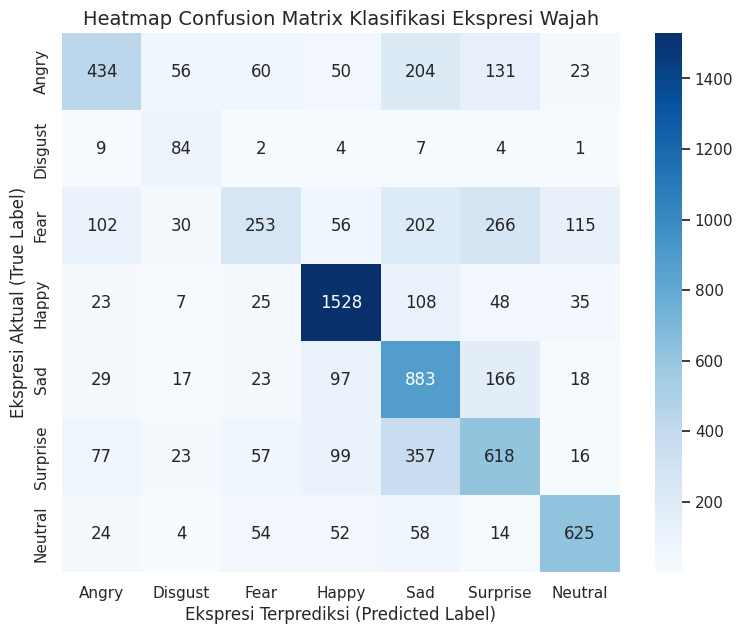

In [ ]:
# Cell 13: Evaluasi Akhir Menggunakan Classification Report dan Heatmap Confusion Matrix

# 1. Melakukan prediksi probabilitas pada data uji
Y_pred = model.predict(test_generator)
# Mengubah probabilitas kelas (soft-max array) menjadi indeks label kelas tunggal (integer)
y_pred_classes = np.argmax(Y_pred, axis=1)
# Memuat label kelas murni dari data uji asli dari generator
y_true_classes = test_generator.classes

# 2. Tampilkan Laporan Klasifikasi Matematika (Precision, Recall, F1-Score per Emosi)
target_names = [emotion_map[i] for i in range(7)]
print("=================== CLASSIFICATION REPORT ===================")
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))

# 3. Membuat dan Memplot Confusion Matrix dalam bentuk Heatmap interaktif
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Heatmap Confusion Matrix Klasifikasi Ekspresi Wajah', fontsize=14)
plt.ylabel('Ekspresi Aktual (True Label)')
plt.xlabel('Ekspresi Terprediksi (Predicted Label)')
plt.show()

**Evaluation**

In [ ]:
# --- Cell Evaluasi Model ---
from sklearn.metrics import classification_report, confusion_matrix

# Predict data uji
Y_pred = model.predict(test_generator)
# Mengubah probabilitas menjadi kelas integer (0-6)
y_pred_classes = np.argmax(Y_pred, axis=1)
# Mengambil label asli dari generator
y_true_classes = test_generator.classes

# Tampilkan Report
print(classification_report(y_true_classes, y_pred_classes, target_names=list(emotion_map.values())))

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
              precision    recall  f1-score   support

       Angry       0.62      0.45      0.52       958
     Disgust       0.38      0.76      0.51       111
        Fear       0.53      0.25      0.34      1024
       Happy       0.81      0.86      0.83      1774
         Sad       0.49      0.72      0.58      1233
    Surprise       0.50      0.50      0.50      1247
     Neutral       0.75      0.75      0.75       831

    accuracy                           0.62      7178
   macro avg       0.58      0.61      0.58      7178
weighted avg       0.62      0.62      0.60      7178



*Model Optimization**

**export model**

In [ ]:
# Cell 14: Export Model ke Format TensorFlow.js untuk Website

# 1. Install library tensorflowjs untuk konversi model
!pip install -q tensorflowjs

import tensorflow as tf
import tensorflowjs as tfjs
import os
from google.colab import files

# 2. Tentukan path model sumber dan folder tujuan export
keras_model_path = '/content/best_emotion_model.keras'
tfjs_target_dir = '/content/emotion_model_tfjs'

if os.path.exists(keras_model_path):
    print("⌛ Memulai proses konversi model ke format TensorFlow.js...")

    # Memuat model Keras
    model = tf.keras.models.load_model(keras_model_path)

    # Konversi model ke format yang bisa dibaca oleh website (tfjs)
    tfjs.converters.save_keras_model(model, tfjs_target_dir)

    print(f"✅ Konversi selesai! File tersimpan di: {tfjs_target_dir}")

    # 3. Mengompres hasil export menjadi file ZIP agar mudah diunduh
    !zip -r emotion_model_web.zip {tfjs_target_dir}

    print("\n--- INSTRUKSI WEBSITE ---")
    print("1. Unduh file 'emotion_model_web.zip' yang baru saja dibuat.")
    print("2. Gunakan library @tensorflow/tfjs di JavaScript Anda.")
    print("3. Load model menggunakan: await tf.loadLayersModel('path/to/model.json');")

    # Opsi: Otomatis memicu unduhan di browser
    files.download('emotion_model_web.zip')
else:
    print("❌ File 'best_emotion_model.keras' tidak ditemukan. Pastikan Anda sudah menjalankan proses training di Cell 11.")

⌛ Memulai proses konversi model ke format TensorFlow.js...


failed to lookup keras version from the file,
    this is likely a weight only file
✅ Konversi selesai! File tersimpan di: /content/emotion_model_tfjs
  adding: content/emotion_model_tfjs/ (stored 0%)
  adding: content/emotion_model_tfjs/group1-shard1of2.bin (deflated 7%)
  adding: content/emotion_model_tfjs/group1-shard2of2.bin (deflated 7%)
  adding: content/emotion_model_tfjs/model.json (deflated 92%)

--- INSTRUKSI WEBSITE ---
1. Unduh file 'emotion_model_web.zip' yang baru saja dibuat.
2. Gunakan library @tensorflow/tfjs di JavaScript Anda.
3. Load model menggunakan: await tf.loadLayersModel('path/to/model.json');


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. Mengompres folder emotion_model_tfjs menjadi file ZIP
!zip -r emotion_model_tfjs.zip emotion_model_tfjs/

# 2. Memanggil perintah download bawaan Google Colab
from google.colab import files
files.download('emotion_model_tfjs.zip')

  adding: emotion_model_tfjs/ (stored 0%)
  adding: emotion_model_tfjs/group1-shard1of2.bin (deflated 7%)
  adding: emotion_model_tfjs/group1-shard2of2.bin (deflated 7%)
  adding: emotion_model_tfjs/model.json (deflated 92%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>